In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

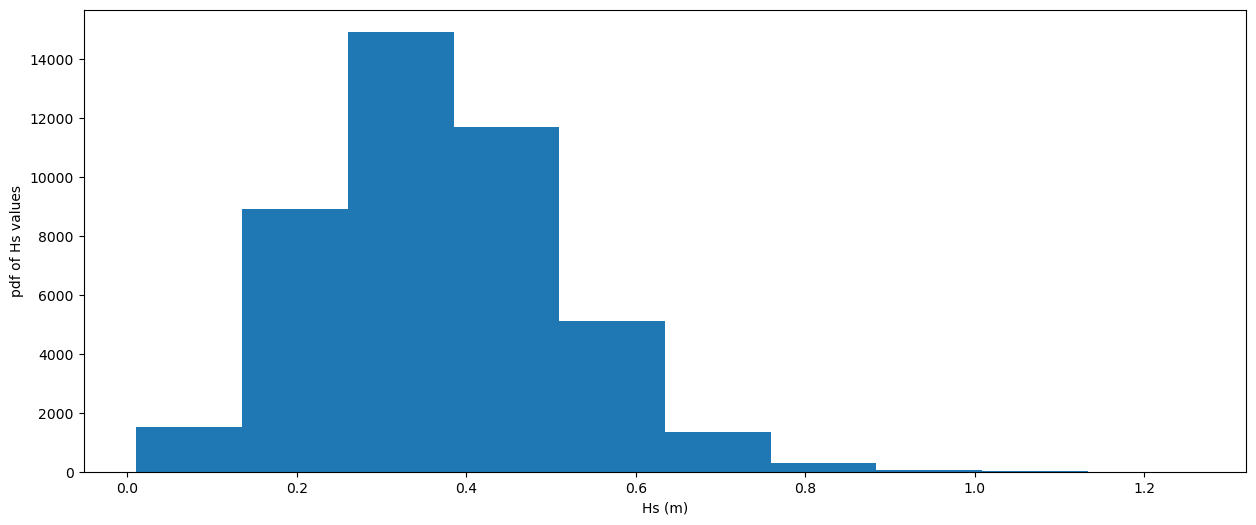

Number of Hs values:  43832

0        1996-01-01 00:00:00
1        1996-01-01 06:00:00
2        1996-01-01 12:00:00
3        1996-01-01 18:00:00
4        1996-01-02 00:00:00
                ...         
43827    2025-12-30 18:00:00
43828    2025-12-31 00:00:00
43829    2025-12-31 06:00:00
43830    2025-12-31 12:00:00
43831    2025-12-31 18:00:00
Name: time, Length: 43832, dtype: object


In [2]:
wave_data = pd.read_csv('total_data.csv')
time_series = wave_data['Hs_swell']
period_series = wave_data['Peak_period']
time_values = wave_data['time']

# 
#  Extract Hs from database and plot histogram
#

fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs values')
ax.hist(time_series, histtype='stepfilled')
plt.show()

#
imax = len(time_series)
print('Number of Hs values: ',imax)
print()
dft = wave_data.get("time")
print(dft)
pass

In [3]:
#
# Peak Over Through code
def pot_method(data, threshold, dtime):
    idx_pot, _ = find_peaks(data, height = threshold, distance = dtime)
    pot_list = data.loc[idx_pot]
    return idx_pot, pot_list
#

figwave = go.Figure()

figwave.add_trace(go.Scatter(
    x=time_values,
    y=time_series,
    mode='lines',
    name='Hs time series'
))

figwave.update_layout(
    xaxis_title='Date',
    yaxis_title='Hs [m]',
    title='Significant wave height time series'
)

figwave.show()

In [4]:
#
# threshold is the Hs threshold value
# dtime is the number of values used in time (here 4 * 3 hour samples = 12 hrs)
#
threshold = 0.5
dtime = 12
tare = threshold

indices,pot_maxima = pot_method(time_series, threshold, dtime)

kmax = len(pot_maxima)
print("Number of peaks based on Threshold: ",threshold," and time ",dtime," is ",kmax)
print('Last part of the calculated Peaks over Threshold values: ')
print(pot_maxima.tail())

Number of peaks based on Threshold:  0.5  and time  12  is  1457
Last part of the calculated Peaks over Threshold values: 
43722    0.527466
43738    0.673218
43768    0.538452
43791    0.787889
43810    0.521973
Name: Hs_swell, dtype: float64


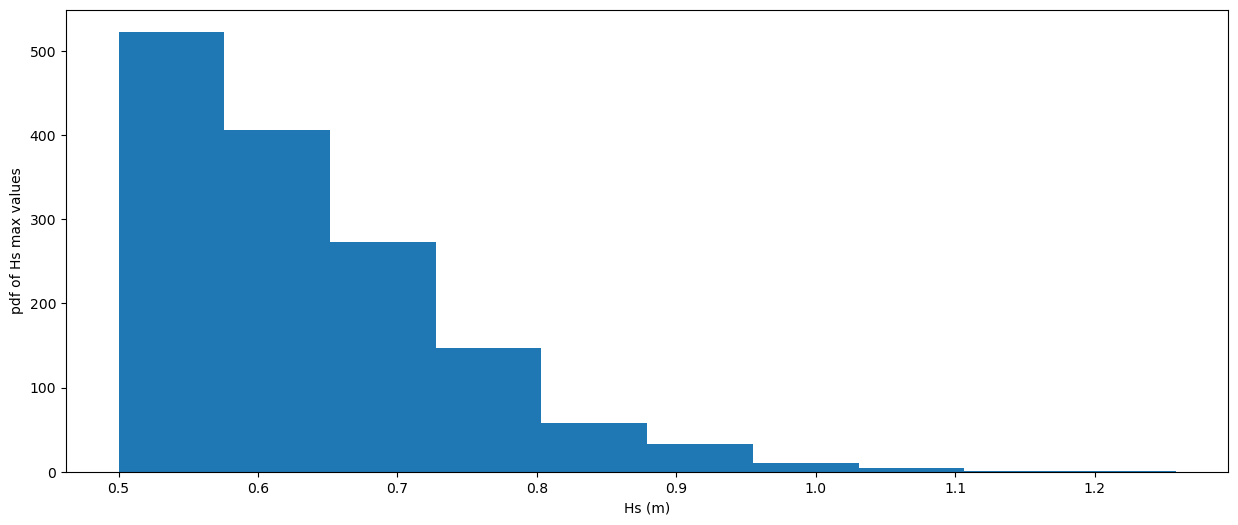

In [5]:
#
#
# following is a subsegment to extract part of the data for visualization
# NB: j is starting value op peaks and range is number of points to be visualized
#
sub_ind = []
j = 100

for i in range(0, 24):
    k = j + i
    val = indices[k]
    sub_ind.append(val)

sub_pot = pot_maxima.loc[sub_ind]

#
# Use dtime as extra space around the selected peaks
#
inst = max(sub_ind[0] - dtime, 0)
inen = min(sub_ind[23] + dtime, len(time_series) - 1)

sub_tim = time_series.iloc[inst:inen+1]
sub_dates = dft.iloc[inst:inen+1]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sub_dates,
    y=sub_tim,
    mode='lines',
    name='Original Plot'
))

fig.add_trace(go.Scatter(
    x=dft.iloc[sub_ind],
    y=sub_pot,
    mode='markers',
    marker=dict(
        size=8,
        color='red',
        symbol='cross'
    ),
    name='Detected Peaks'
))

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Hs [m]',
    title='Detected POT Peaks'
)

fig.show()

#
pot_time = []
for i in range(0,kmax):
    val = indices[i]
    pot_time.append(dft[val])
#
fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs max values')
ax.hist(pot_maxima, histtype='stepfilled')
plt.show()
#
pass

In [6]:
array = np.array([indices, 
         pot_time,
         pot_maxima,
         period_series.loc[indices]
         ])

array = array.T

df = pd.DataFrame(array, columns=['index', 'pot_time', 'pot_maxima', 'Peak_period'])

df.to_csv('EVA result POT swell waves.csv', index=False)


In [7]:
import reliability.Fitters as rf

In [8]:
dfmax = []
for it in pot_maxima.items():
    val = it[1] - tare # pot_maxima[i]
    dfmax.append(val)    
dfmax.sort()

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1457/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         0.14034      0.00327344  0.134069  0.146905
     Beta         1.17891       0.0247372   1.13141    1.2284 

Goodness of fit    Value
 Log-likelihood  1510.83
           AICc -3017.64
            BIC -3007.08
             AD  2.89984 



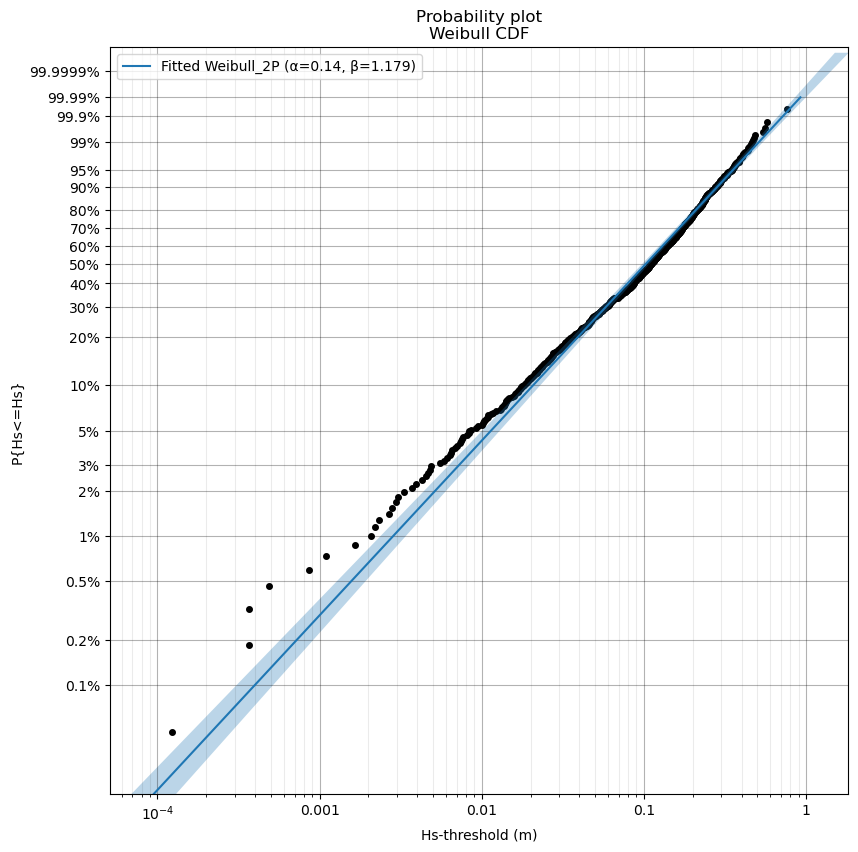

In [9]:
waw2 = rf.Fit_Weibull_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

Results from Fit_Weibull_3P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1457/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         0.14034      0.00327344  0.134069  0.146905
     Beta         1.17891       0.0247372   1.13141    1.2284
    Gamma               0               0         0         0 

Goodness of fit    Value
 Log-likelihood  1510.83
           AICc -3015.64
            BIC  -2999.8
             AD  2.89984 



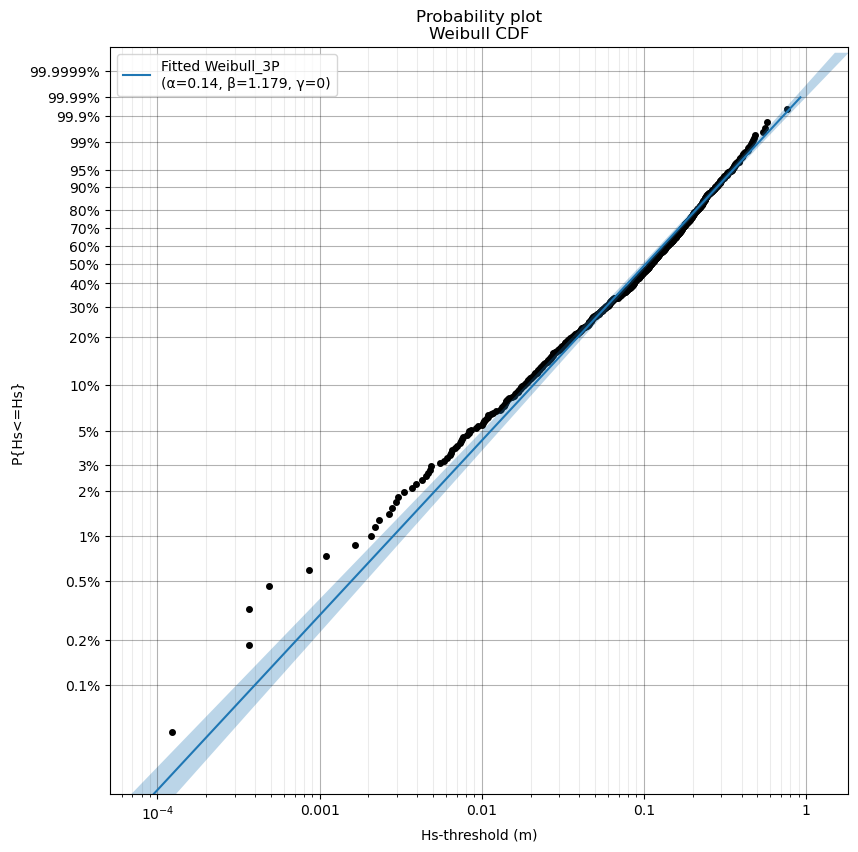

In [10]:
#
#  Weibull 3P fit delivers alpha = scale factor, beta = shape factor & gamma = location factor

waw3 = rf.Fit_Weibull_3P(failures=dfmax)

plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()


Results from Fit_Gumbel_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1457/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
       Mu        0.191527      0.00392798  0.183828  0.199225
    Sigma        0.140978       0.0022864  0.136568  0.145532 

Goodness of fit    Value
 Log-likelihood  792.599
           AICc -1581.19
            BIC -1570.63
             AD      NaN 



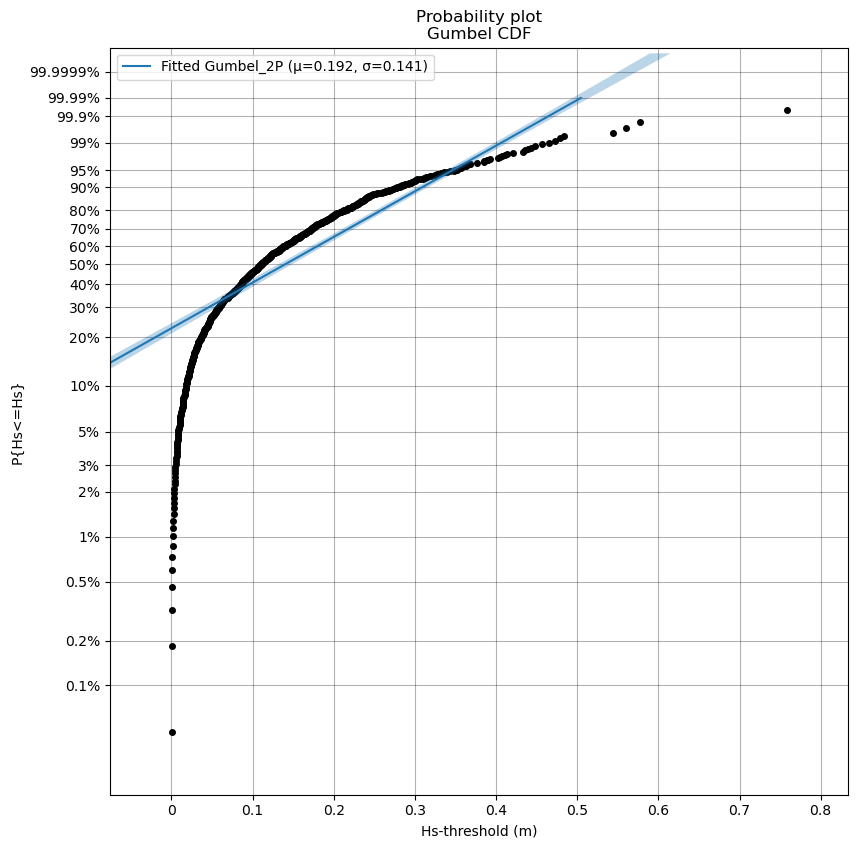

In [11]:
wag = rf.Fit_Gumbel_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

Results from Fit_Exponential_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1457/0 (0% right censored) 

Parameter  Point Estimate  Standard Error    Lower CI    Upper CI
   Lambda         7.52012        0.197013     7.14372     7.91634
 1/Lambda        0.132977      0.00348374    0.126321    0.139983
    Gamma     2.20703e-05               0 2.20703e-05 2.20703e-05 

Goodness of fit    Value
 Log-likelihood  1482.62
           AICc -2961.22
            BIC -2950.66
             AD  14.2225 



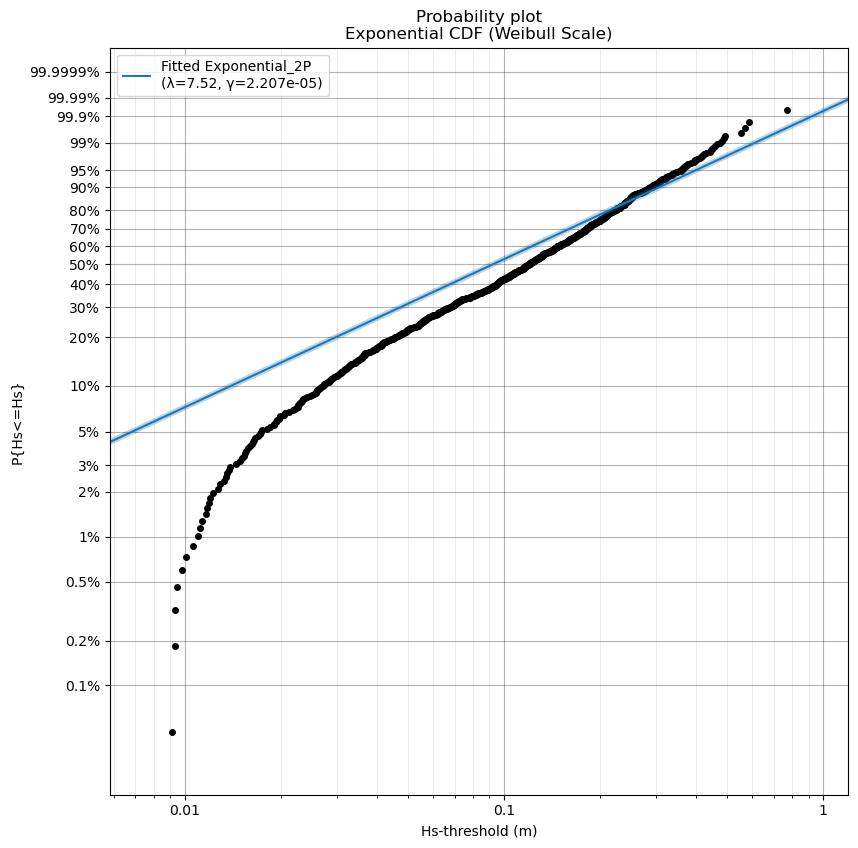

In [12]:
wae = rf.Fit_Exponential_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

In [13]:
#
#  Determine return period values
#
#
# define exceedance value for 100 yr return
# 
treturn = 200
numberyears = 30
numb = len(pot_maxima) / numberyears
prob = 1 - 1/(numb * treturn)
print(prob)

0.9998970487302676


In [14]:
# Weibull 2
X_lower,X_point,X_upper = waw2.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull2P ',treturn,'Year return value is ',X_point,' (m)')

# Weibull 3
X_lower,X_point,X_upper = waw3.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull3P ',treturn,'Year return value is ',X_point,' (m)')

# Gumbel
X_lower,X_point,X_upper = wag.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Gumbel ',treturn,'Year return value is ',X_point,' (m)')

# Exponential
X_lower,X_point,X_upper = wae.distribution.CDF(CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Exponential ',treturn,'Year return value is ',X_point,' (m)')

Weibull2P  200 Year return value is  1.4203570199308182  (m)
Weibull3P  200 Year return value is  1.4203570199308182  (m)
Gumbel  200 Year return value is  1.0040986706347974  (m)
Exponential  200 Year return value is  1.7209146002047953  (m)


c:\Users\jholl\tudelft-conda\envs\mude-base\Lib\site-packages\reliability\Fitters.py:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 1457/0 (0% right censored) 

   Distribution     Alpha    Beta       Gamma   Alpha 1   Beta 1  Alpha 2  Beta 2 Proportion 1 DS       Mu    Sigma  Lambda  Log-likelihood     AICc      BIC       AD optimizer
        Beta_2P   1.11038 7.27122                                                                                                   1517.33 -3030.64 -3020.08   1.7245       TNC
     Weibull_CR                                0.208831 0.945612  0.28762 1.89339                                                   1522.79 -3037.55 -3016.44 0.443535       TNC
Weibull_Mixture                               0.0954837 0.966693 0.190812 1.72412     0.507098                                      1523.62  -3037.2 -3010.82 0.324851       TNC
     Weibull_2P   0.14034 1.17891                                                                                                   1510.83 -3017.64 -3007.08  2.89984       TNC
     Weib

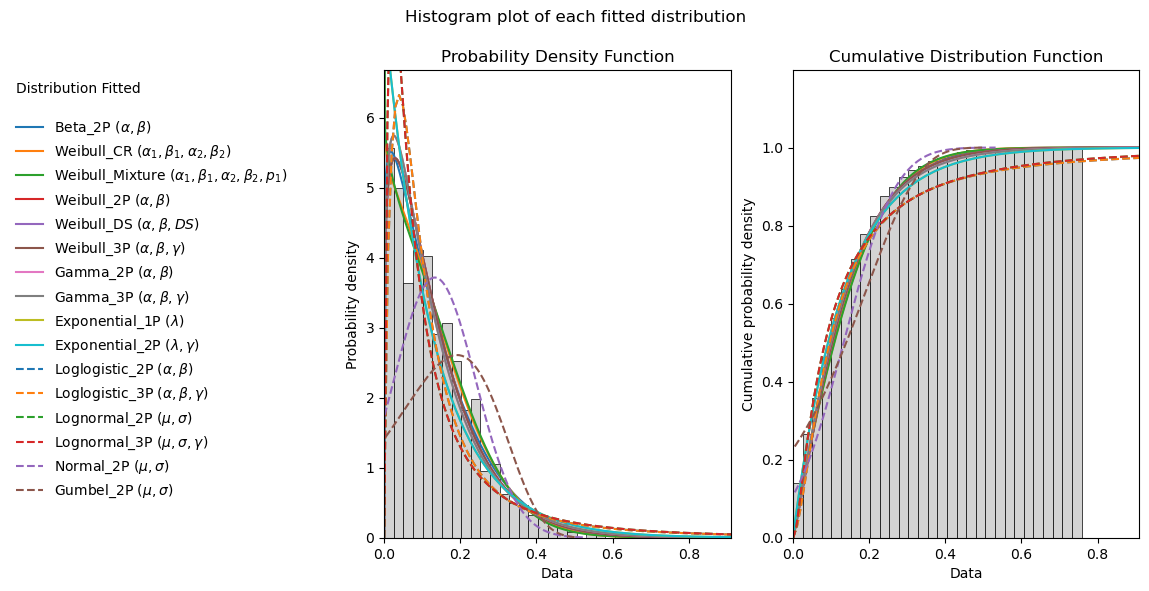

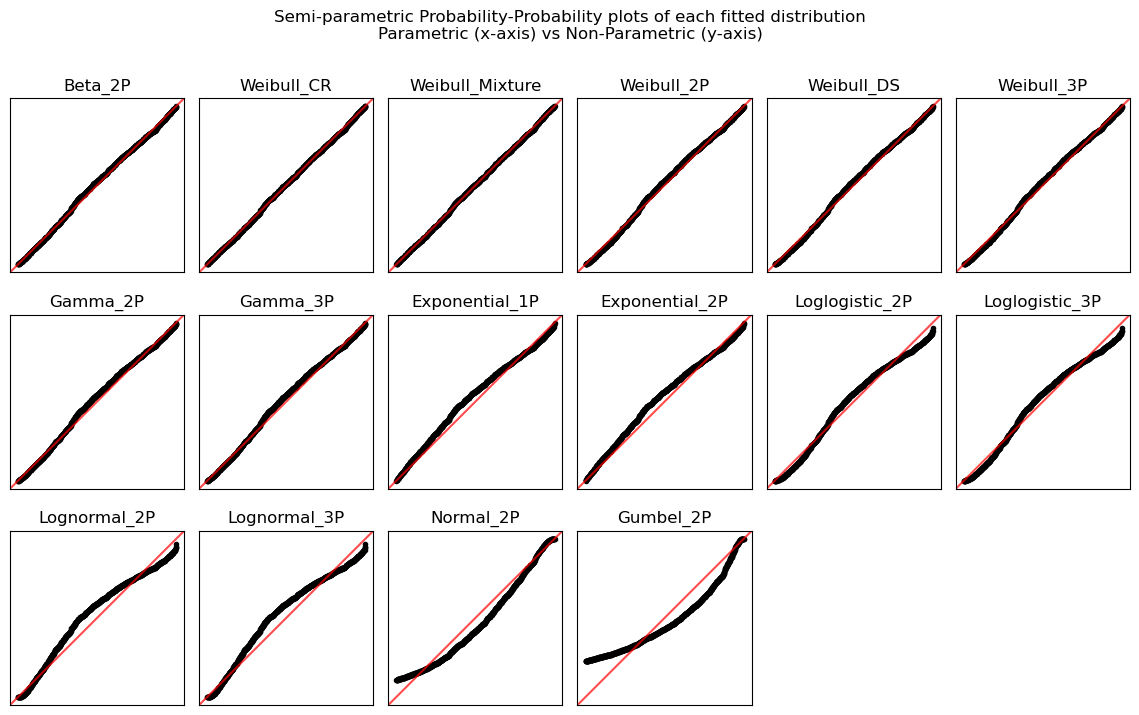

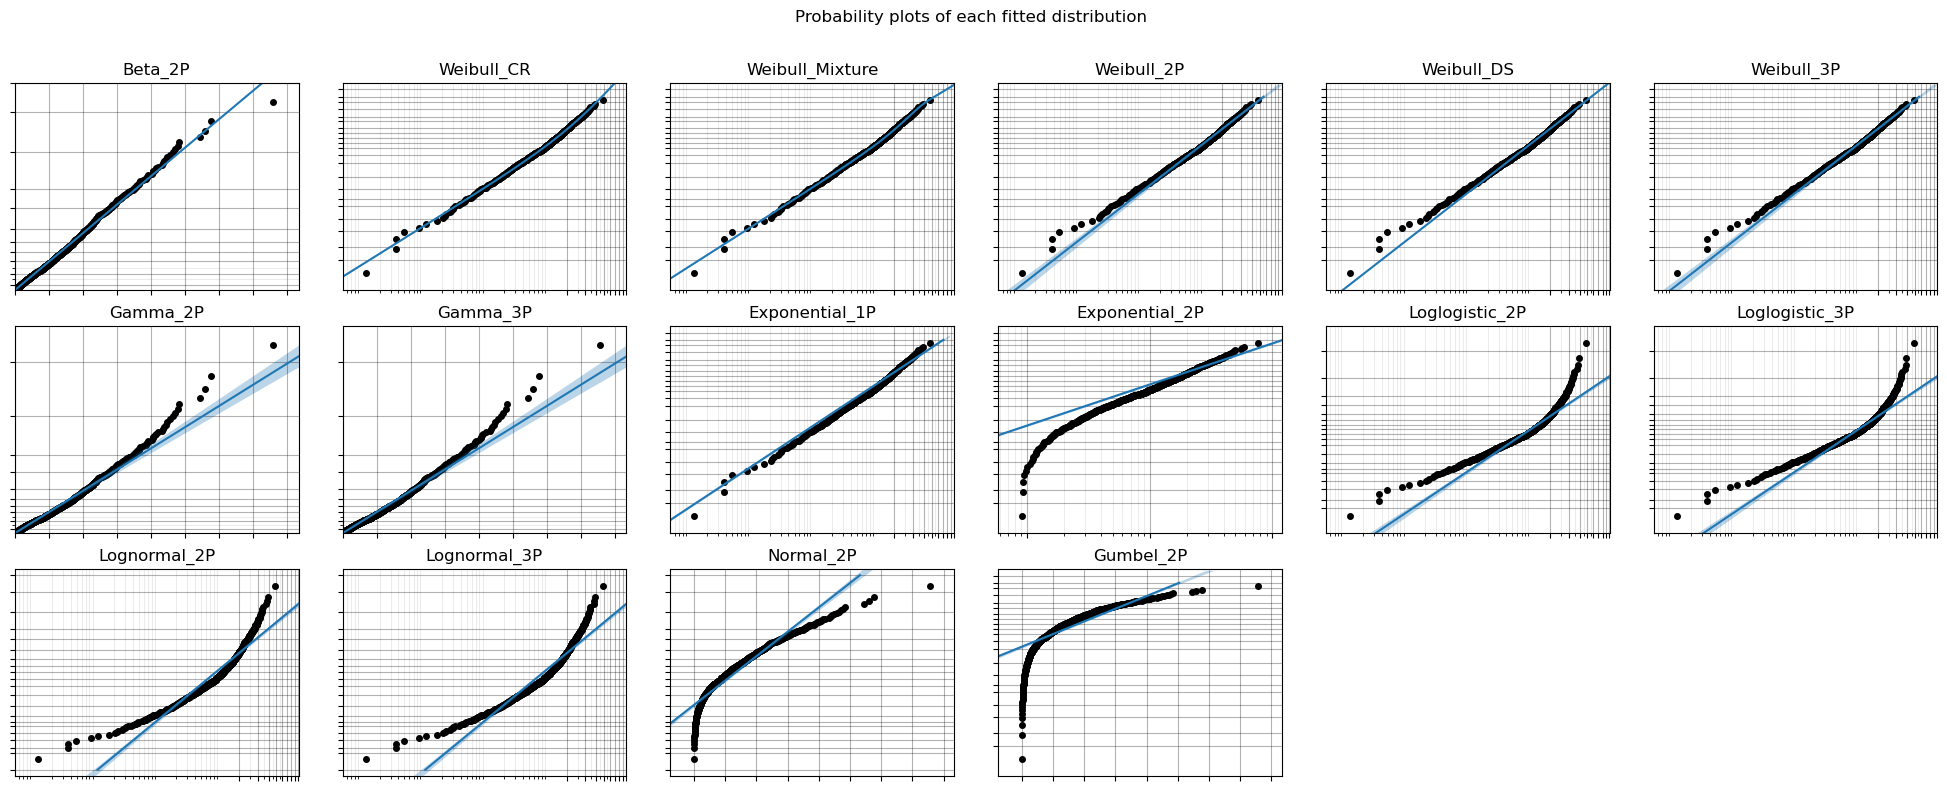

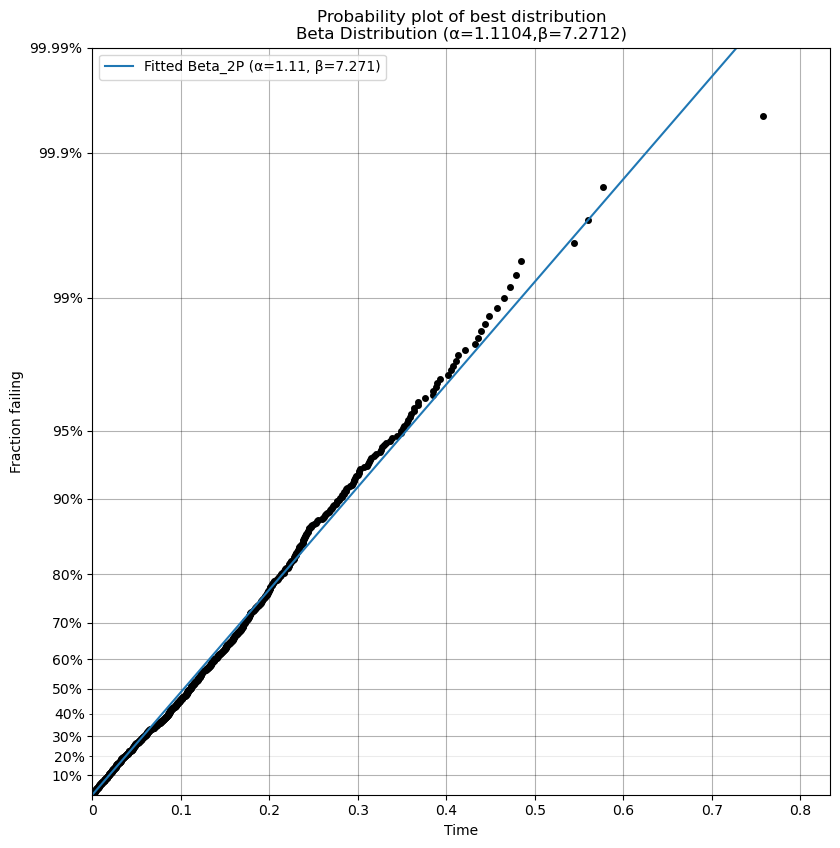

The best fitting distribution was: Beta_2P


,Distribution,Alpha,Beta,Gamma,...,AICc,BIC,AD,optimizer
0,Beta_2P,1.11038,7.27122,,...,-3030.64,-3020.08,1.7245,TNC
0,Weibull_CR,,,,...,-3037.55,-3016.44,0.443535,TNC
0,Weibull_Mixture,,,,...,-3037.2,-3010.82,0.324851,TNC
0,Weibull_2P,0.14034,1.17891,,...,-3017.64,-3007.08,2.89984,TNC
0,Weibull_DS,0.14034,1.17891,,...,-3015.64,-2999.8,2.89984,TNC
0,Weibull_3P,0.14034,1.17891,0,...,-3015.64,-2999.8,2.89984,TNC
0,Gamma_2P,0.10772,1.23468,,...,-2998.79,-2988.23,4.82473,TNC
0,Gamma_3P,0.10772,1.23468,0,...,-2996.78,-2980.94,4.82473,TNC
0,Exponential_1P,,,,...,-2962.75,-2957.47,14.2526,TNC
0,Exponential_2P,,,2.20703e-05,...,-2961.22,-2950.66,14.2225,TNC


Parameters: [1.11037504 7.27122431]


In [15]:
# Fit all distributions and print best distribution safely

results = rf.Fit_Everything(failures=dfmax)

print("The best fitting distribution was:", results.best_distribution_name)

# Show the fitted distribution ranking table
display(results.results)

# Try to print parameters, but avoid crashing for competing risks models
best_dist = results.best_distribution

if hasattr(best_dist, "parameters"):
    print("Parameters:", best_dist.parameters)
else:
    print("No direct .parameters attribute for this distribution type.")
    print("Best distribution object:")
    print(best_dist)

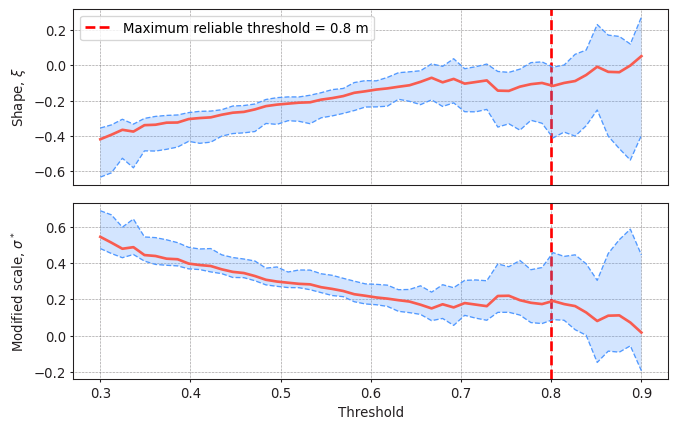

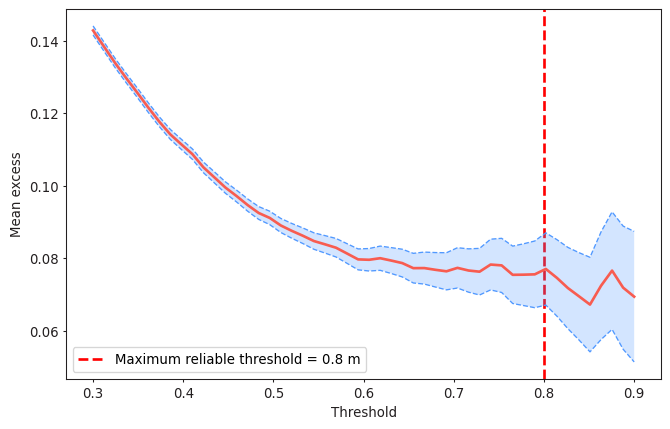

Number of POT peaks: 1457
Minimum time spacing [h]: 72.0
Number of peaks closer than 72 h: 0
GPD shape ξ: -0.18522082232220574
GPD scale σ: 0.15657460261699435
GPD location: 0
Upper bound Hs: 1.3453401764118125
Record length [years]: 30.00130050582832
POT peaks per year λ: 48.5645613834957


,Return period [years],Hs_swell POT-GPD [m]
0,1,0.934
1,10,1.077
2,50,1.146
3,100,1.17
4,200,1.191
5,490,1.215
6,500,1.215
7,1000,1.231
8,10000,1.271


In [16]:
# ============================================================
# THRESHOLD CHECK + DESIGN VALUES - SWELL WAVES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pyextremes import plot_parameter_stability, plot_mean_residual_life

# Make sure time is datetime
wave_data["time"] = pd.to_datetime(wave_data["time"])

# ============================================================
# THRESHOLD CHECK - WS2 / pyExtremes method
# ============================================================

data = (
    wave_data[["time", "Hs_swell"]]
    .dropna()
    .assign(time=lambda df: pd.to_datetime(df["time"]))
    .set_index("time")["Hs_swell"]
    .sort_index()
)

data.name = "Hs"

r = "72H"

# Threshold used for POT extraction in this notebook
threshold = 0.5

# Maximum reliable threshold shown in the plot
maximum_threshold = 0.8

# Realistic threshold range in metres for swell waves
thresholds = np.linspace(0.3, 0.9, 50)

# Parameter stability plot
plot_parameter_stability(
    data,
    thresholds=thresholds,
    r=r,
    alpha=0.95
)

for ax in plt.gcf().axes:
    ax.axvline(
        maximum_threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Maximum reliable threshold = {maximum_threshold:.1f} m"
    )

for ax in plt.gcf().axes:
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend()
        break

plt.show()

# Mean residual life plot
plot_mean_residual_life(
    data,
    thresholds=thresholds
)

for ax in plt.gcf().axes:
    ax.axvline(
        maximum_threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Maximum reliable threshold = {maximum_threshold:.1f} m"
    )
    ax.legend()

plt.show()


# ============================================================
# READ POT PEAKS
# ============================================================

pot_df = pd.read_csv("EVA result POT swell waves.csv")
pot_df["pot_time"] = pd.to_datetime(pot_df["pot_time"])

pot_maxima = pot_df["pot_maxima"].astype(float)
excess = pot_maxima - threshold

pot_df["dt_hours"] = pot_df["pot_time"].diff().dt.total_seconds() / 3600

print("Number of POT peaks:", len(pot_df))
print("Minimum time spacing [h]:", pot_df["dt_hours"].min())
print("Number of peaks closer than 72 h:", (pot_df["dt_hours"] < 72).sum())


# ============================================================
# FIT GPD TO POT EXCESSES
# ============================================================

gpd_shape, gpd_loc, gpd_scale = stats.genpareto.fit(excess, floc=0)

print("GPD shape ξ:", gpd_shape)
print("GPD scale σ:", gpd_scale)
print("GPD location:", gpd_loc)

if gpd_shape < 0:
    upper_bound = threshold - gpd_scale / gpd_shape
    print("Upper bound Hs:", upper_bound)


# ============================================================
# RETURN VALUES
# ============================================================

record_years = (
    wave_data["time"].max() - wave_data["time"].min()
).total_seconds() / (365.2425 * 24 * 3600)

lambda_pot = len(pot_maxima) / record_years

print("Record length [years]:", record_years)
print("POT peaks per year λ:", lambda_pot)

def pot_gpd_return_value(R):
    p_non_exceed_excess = 1 - 1 / (lambda_pot * R)
    return threshold + stats.genpareto.ppf(
        p_non_exceed_excess,
        c=gpd_shape,
        loc=0,
        scale=gpd_scale
    )

return_periods = [1, 10, 50, 100, 200, 490, 500, 1000, 10000]

design_table_swell = pd.DataFrame({
    "Return period [years]": return_periods,
    "Hs_swell POT-GPD [m]": [pot_gpd_return_value(R) for R in return_periods]
})

design_table_swell["Hs_swell POT-GPD [m]"] = design_table_swell["Hs_swell POT-GPD [m]"].round(3)

display(design_table_swell)

In [17]:
# ============================================================
# SCATTERPLOT: PERIOD VS WAVE HEIGHT
# Full dataset + detected POT peaks
# ============================================================

import plotly.graph_objects as go

# Use the correct period column
period_series = wave_data["Peak_period"]

fig = go.Figure()

# All wave data points
fig.add_trace(go.Scatter(
    x=period_series,
    y=time_series,
    mode="markers",
    marker=dict(
        size=4,
        opacity=0.35,
        color="blue"
    ),
    name="All wave data"
))

# POT peaks with corresponding period at the same index/timestamp
fig.add_trace(go.Scatter(
    x=period_series.iloc[indices],
    y=pot_maxima.values,
    mode="markers",
    marker=dict(
        size=8,
        color="red",
        symbol="cross"
    ),
    name="Detected POT peaks"
))

fig.update_layout(
    title="Wave height vs peak wave period",
    xaxis_title="Peak wave period Tp [s]",
    yaxis_title="Significant wave height Hs [m]",
    template="plotly_white"
)

fig.show()